In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [7]:
df = pd.read_csv('D:\SIT\Sem.5\PBL V\Datasets\Indian_crop_production_yield_dataset.csv')

<>:1: SyntaxWarning: invalid escape sequence '\S'
<>:1: SyntaxWarning: invalid escape sequence '\S'
C:\Users\SHANTANU\AppData\Local\Temp\ipykernel_27124\998312648.py:1: SyntaxWarning: invalid escape sequence '\S'
  df = pd.read_csv('D:\SIT\Sem.5\PBL V\Datasets\Indian_crop_production_yield_dataset.csv')


In [8]:
df.shape

(575879, 8)

In [9]:
df.head(2)

,State_Name,District_Name,Crop_Year,Season,Crop,Area,Production,yield
0,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Arecanut,1254.0,2000.0,1.594896
1,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Other Kharif pulses,2.0,1.0,0.500000


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 575879 entries, 0 to 575878
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   State_Name     575879 non-null  object 
 1   District_Name  575879 non-null  object 
 2   Crop_Year      575879 non-null  int64  
 3   Season         575879 non-null  object 
 4   Crop           575879 non-null  object 
 5   Area           575879 non-null  float64
 6   Production     575879 non-null  float64
 7   yield          575879 non-null  float64
dtypes: float64(3), int64(1), object(4)
memory usage: 35.1+ MB


In [11]:
df['State_Name'].value_counts()

State_Name
Uttar Pradesh                  77804
Madhya Pradesh                 52007
Karnataka                      48393
Bihar                          43555
Assam                          32798
Rajasthan                      31760
Tamil Nadu                     31312
Maharashtra                    30042
Odisha                         29625
Andhra Pradesh                 25719
Chhattisgarh                   25095
Gujarat                        22316
West Bengal                    16194
Uttarakhand                    11453
Haryana                        10844
Telangana                      10253
Nagaland                        9578
Kerala                          8629
Himachal Pradesh                7411
Punjab                          7229
Meghalaya                       7189
Arunachal Pradesh               6889
Jharkhand                       6257
Jammu and Kashmir               5974
Manipur                         4358
Tripura                         3969
Mizoram                    

In [12]:
df.shape

(575879, 8)

In [13]:
print(df.describe())

           Crop_Year          Area    Production         yield
count  575879.000000  5.758790e+05  5.758790e+05  5.758790e+05
mean     2007.559402  1.186614e+04  5.689498e+07  4.779376e+03
std         6.174890  4.407750e+04  1.656008e+09  7.109329e+04
min      1997.000000  8.000000e-03  0.000000e+00  0.000000e+00
25%      2002.000000  8.200000e+01  7.270000e+02  1.346025e+00
50%      2007.000000  5.870000e+02  1.220000e+04  4.484848e+01
75%      2013.000000  4.388000e+03  1.859000e+05  1.314807e+02
max      2020.000000  8.580100e+06  1.597800e+11  4.395833e+06


In [14]:
print(df.isnull().sum())

State_Name       0
District_Name    0
Crop_Year        0
Season           0
Crop             0
Area             0
Production       0
yield            0
dtype: int64


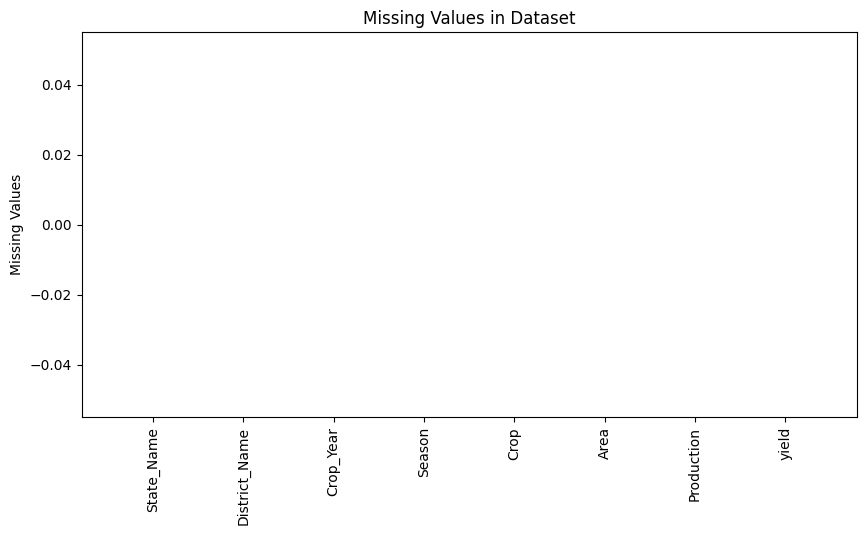

In [15]:
missing = df.isnull().sum()

plt.figure(figsize=(10,5))

plt.bar(missing.index, missing.values)

plt.xticks(rotation=90)

plt.ylabel("Missing Values")

plt.title("Missing Values in Dataset")

plt.show()

In [16]:
df.duplicated().sum()

np.int64(0)

In [17]:
# df = df.drop_duplicates()

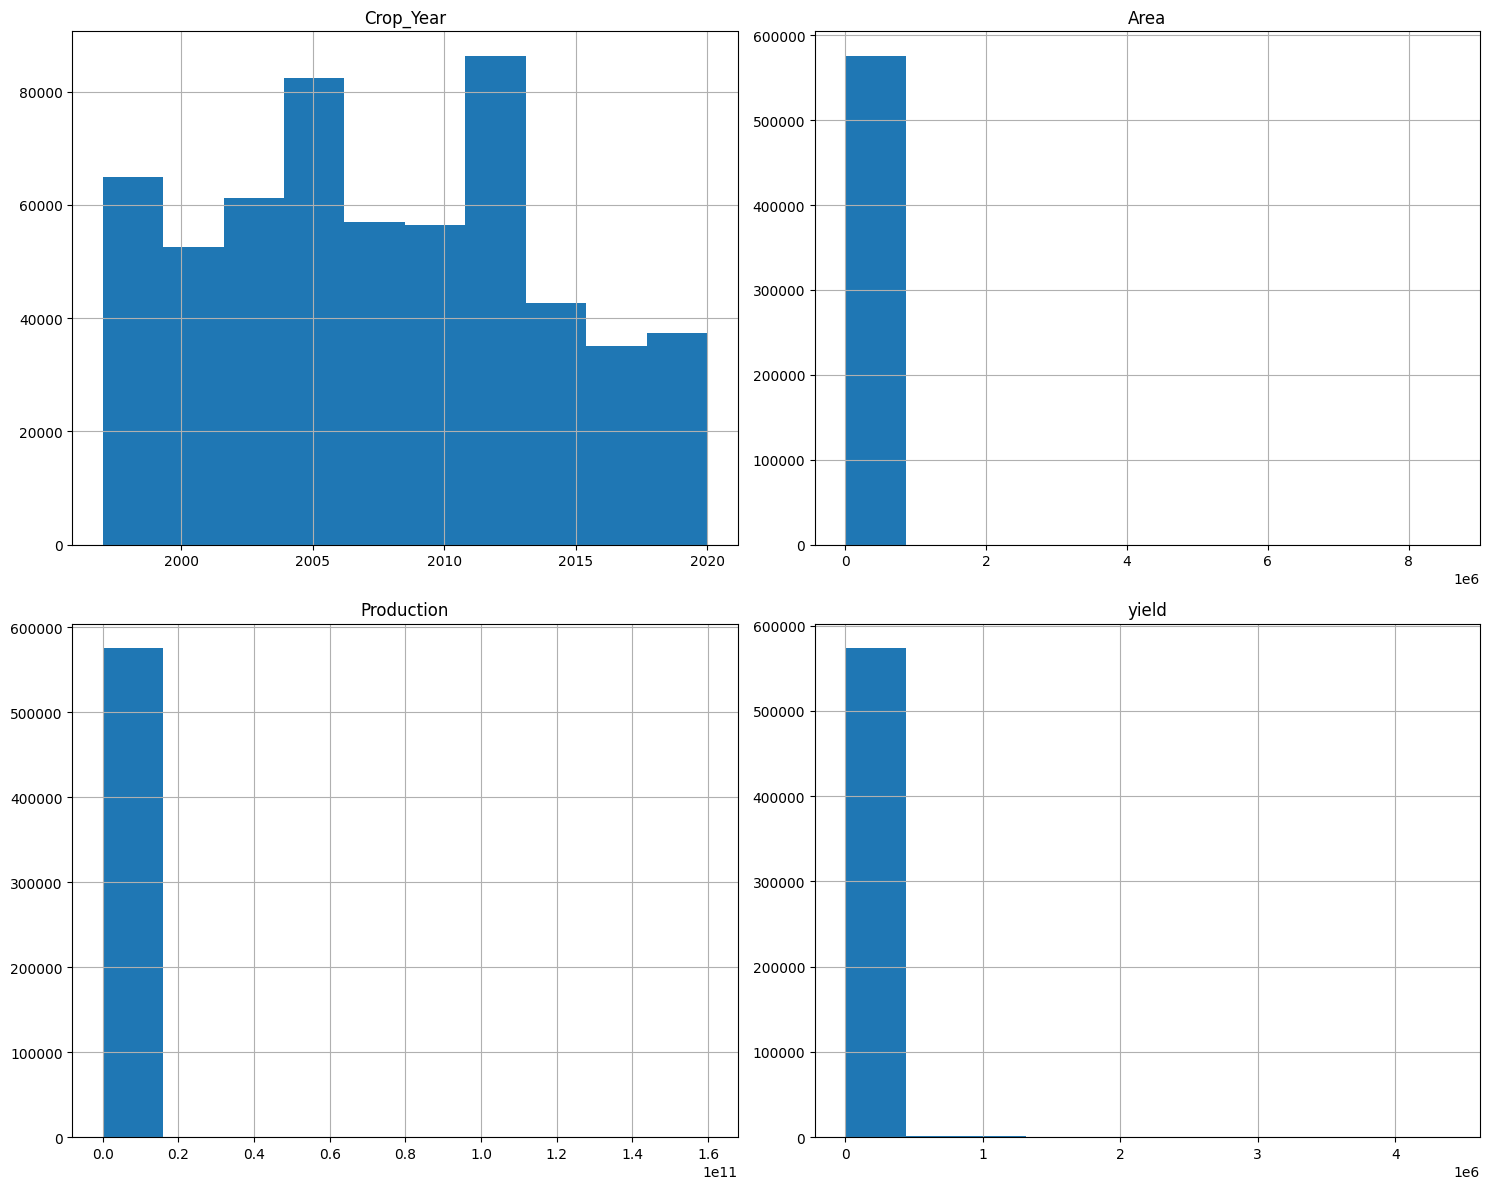

In [18]:
numeric = df.select_dtypes(include='number')

numeric.hist(figsize=(15,12))

plt.tight_layout()

plt.show()

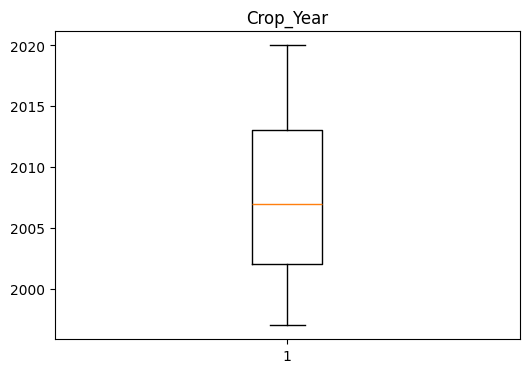

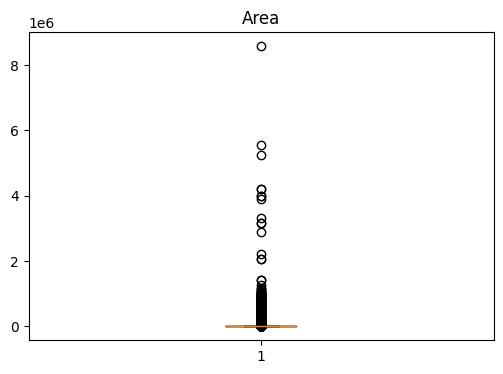

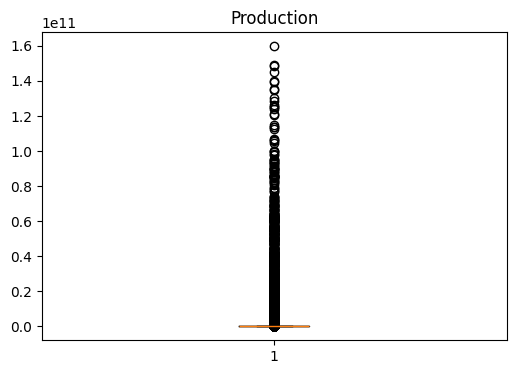

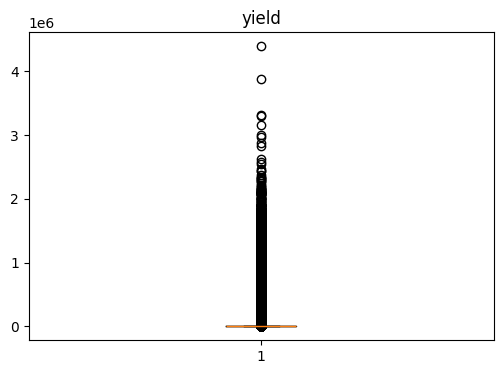

In [19]:
for column in numeric.columns:

    plt.figure(figsize=(6,4))

    plt.boxplot(df[column].dropna())

    plt.title(column)

    plt.show()

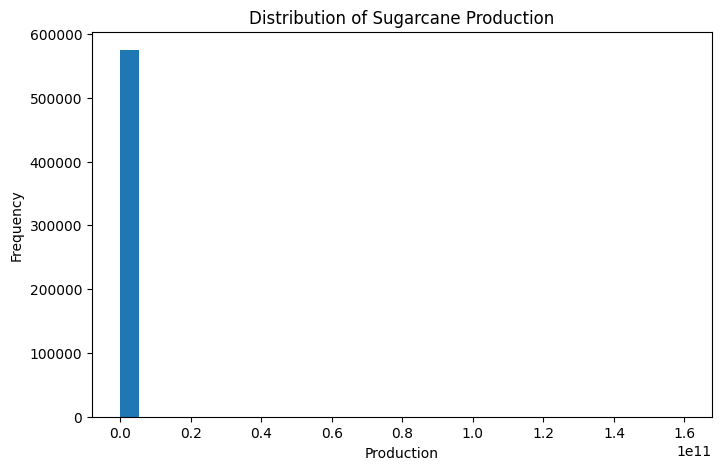

In [20]:
plt.figure(figsize=(8,5))

plt.hist(df["Production"], bins=30)

plt.xlabel("Production")

plt.ylabel("Frequency")

plt.title("Distribution of Sugarcane Production")

plt.show()

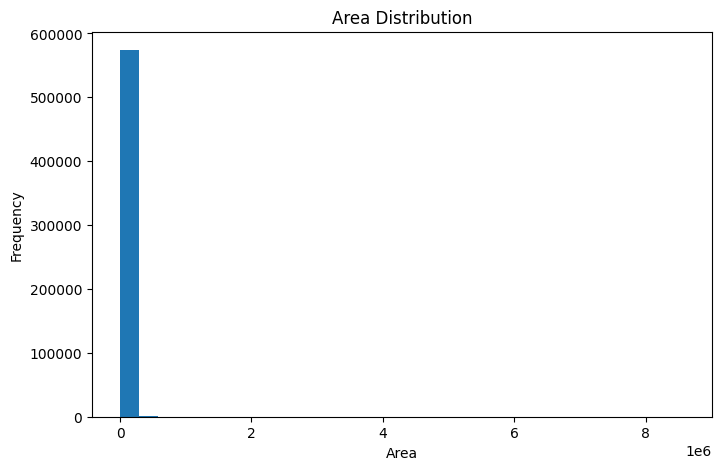

In [21]:
plt.figure(figsize=(8,5))

plt.hist(df["Area"], bins=30)

plt.xlabel("Area")

plt.ylabel("Frequency")

plt.title("Area Distribution")

plt.show()

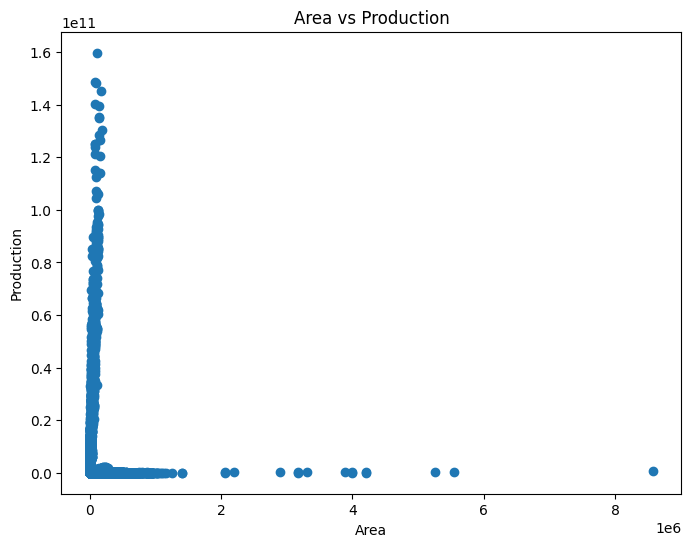

In [22]:
plt.figure(figsize=(8,6))

plt.scatter(df["Area"], df["Production"])

plt.xlabel("Area")

plt.ylabel("Production")

plt.title("Area vs Production")

plt.show()

Yield Distribution

In [23]:
df["Yield"] = df["Production"] / df["Area"]

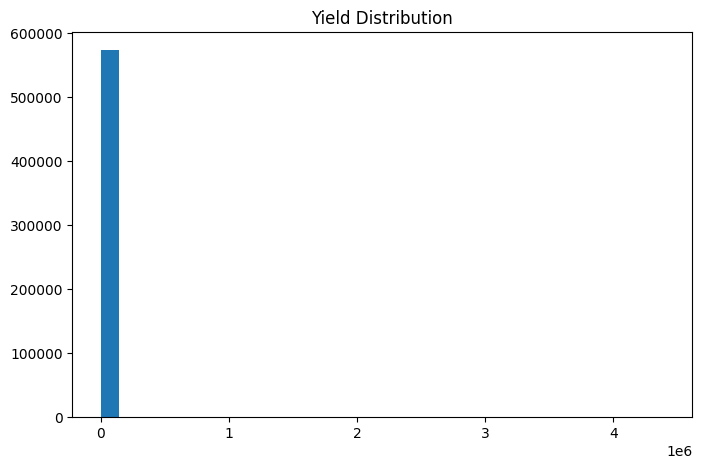

In [24]:
plt.figure(figsize=(8,5))

plt.hist(df["Yield"], bins=30)

plt.title("Yield Distribution")

plt.show()

Production Trend Over Years

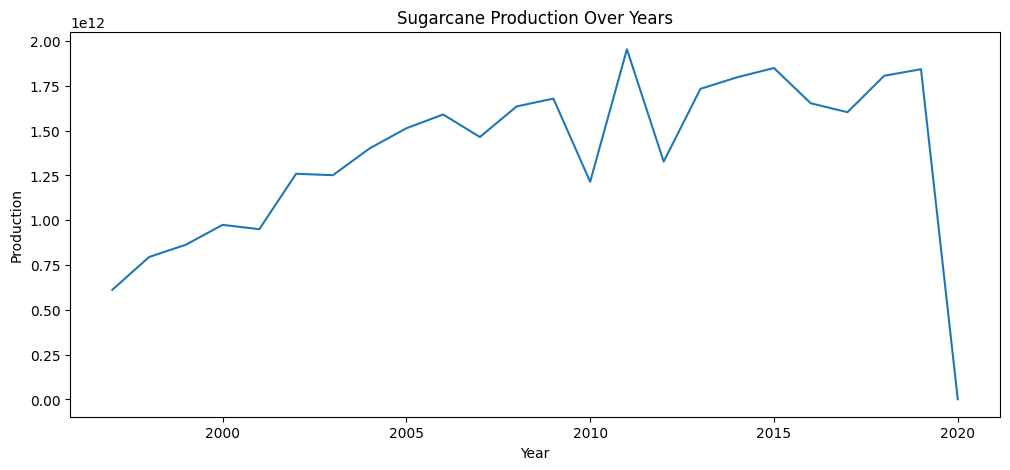

In [25]:
yearly = df.groupby("Crop_Year")["Production"].sum()

plt.figure(figsize=(12,5))

plt.plot(yearly.index, yearly.values)

plt.xlabel("Year")

plt.ylabel("Production")

plt.title("Sugarcane Production Over Years")

plt.show()

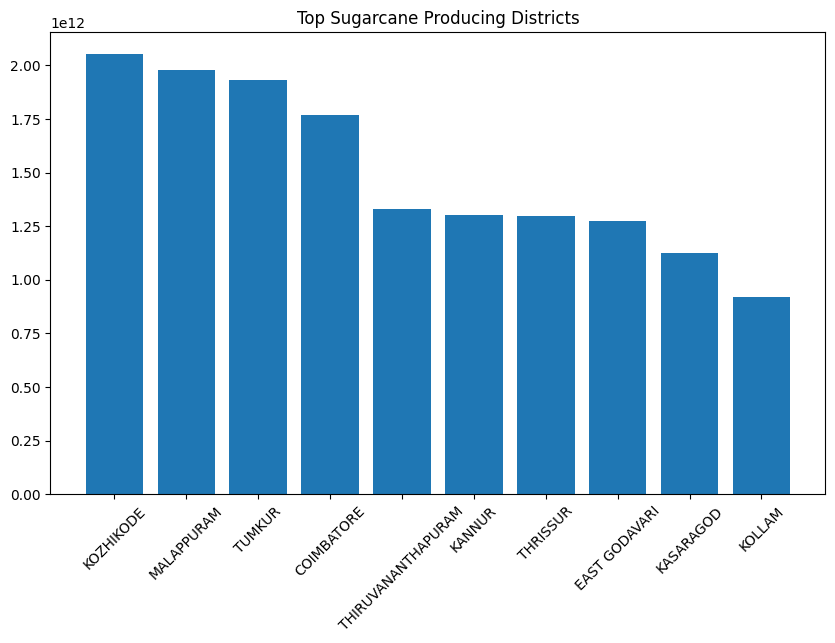

In [26]:
district = df.groupby("District_Name")["Production"].sum()

district = district.sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))

plt.bar(district.index, district.values)

plt.xticks(rotation=45)

plt.title("Top Sugarcane Producing Districts")

plt.show()

In [27]:
corr = numeric.corr()

print(corr)

            Crop_Year      Area  Production     yield
Crop_Year    1.000000 -0.023530    0.010634  0.021415
Area        -0.023530  1.000000    0.039189  0.000058
Production   0.010634  0.039189    1.000000  0.438115
yield        0.021415  0.000058    0.438115  1.000000


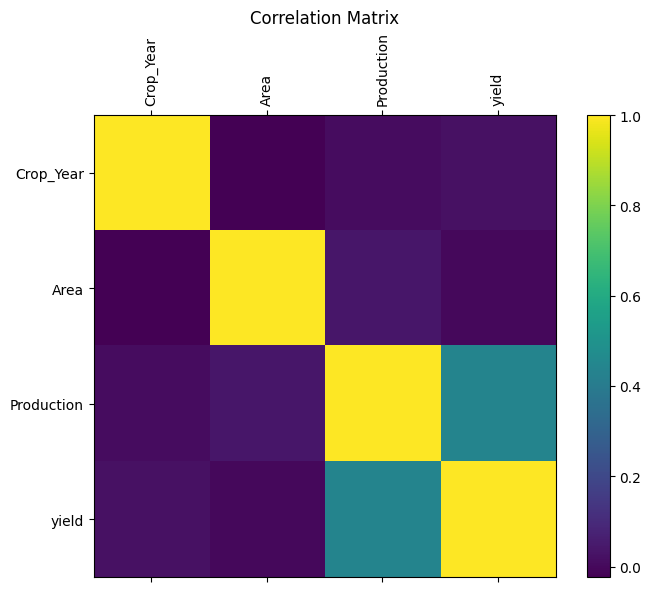

In [28]:
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111)

cax = ax.matshow(corr)

fig.colorbar(cax)

ax.set_xticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=90)

ax.set_yticks(range(len(corr.columns)))
ax.set_yticklabels(corr.columns)

plt.title("Correlation Matrix")

plt.show()

In [29]:
print(df[df["Yield"] > df["Yield"].quantile(0.99)])

print(df[df["Area"] == 0])

print(df[df["Production"] == 0])

            State_Name   District_Name  Crop_Year      Season       Crop  \
607     Andhra Pradesh       ANANTAPUR       2006  Whole Year    Coconut   
661     Andhra Pradesh       ANANTAPUR       2008  Whole Year    Coconut   
784     Andhra Pradesh       ANANTAPUR       2011  Whole Year    Coconut   
849     Andhra Pradesh       ANANTAPUR       2012  Whole Year    Coconut   
983     Andhra Pradesh       ANANTAPUR       2014  Whole Year    Coconut   
...                ...             ...        ...         ...        ...   
575576     West Bengal  MEDINIPUR WEST       1998  Whole Year  Sugarcane   
575577     West Bengal  MEDINIPUR WEST       1999  Whole Year  Sugarcane   
575591     West Bengal         PURULIA       1997  Whole Year  Sugarcane   
575592     West Bengal         PURULIA       1998  Whole Year  Sugarcane   
575593     West Bengal         PURULIA       1999  Whole Year  Sugarcane   

          Area  Production         yield         Yield  
607      790.0   6404076.0   8

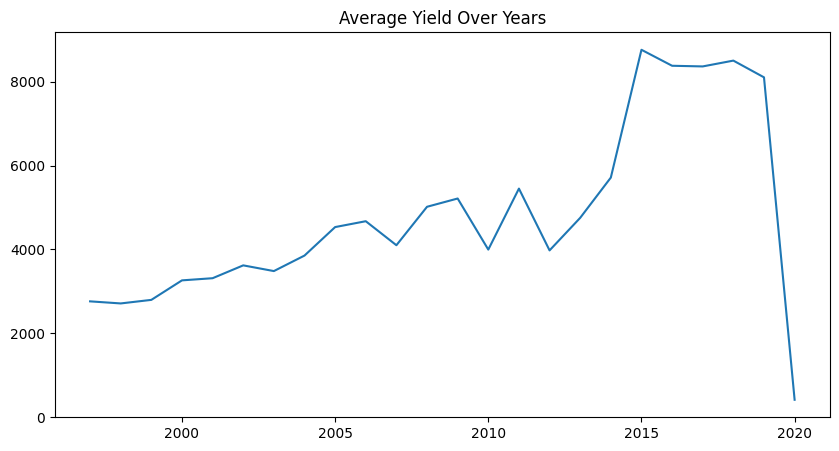

In [30]:
yield_year = df.groupby("Crop_Year")["Yield"].mean()

plt.figure(figsize=(10,5))

plt.plot(yield_year.index, yield_year.values)

plt.title("Average Yield Over Years")

plt.show()

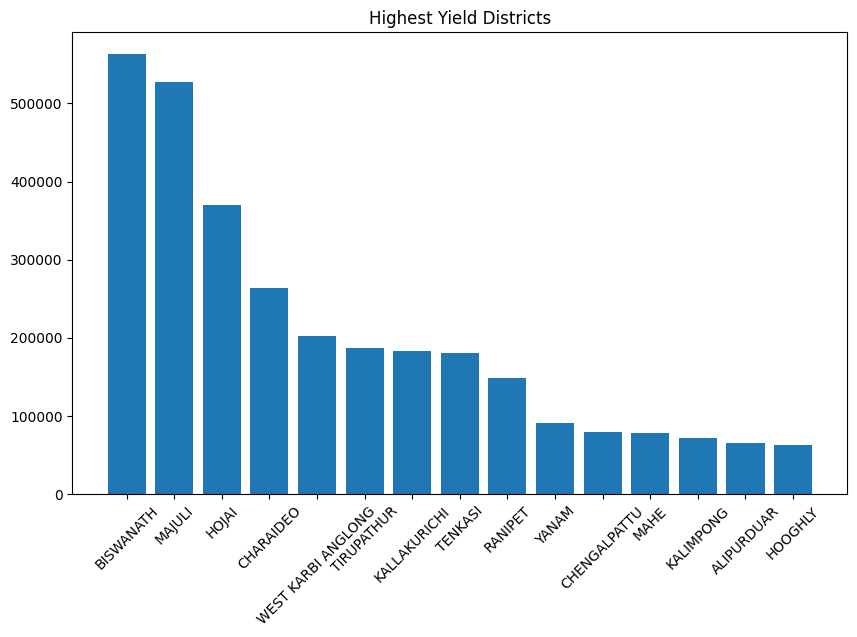

In [31]:
yield_dist = df.groupby("District_Name")["Yield"].mean()

yield_dist = yield_dist.sort_values(ascending=False).head(15)

plt.figure(figsize=(10,6))

plt.bar(yield_dist.index, yield_dist.values)

plt.xticks(rotation=45)

plt.title("Highest Yield Districts")

plt.show()

In [32]:
df = df[
    (df["State_Name"] == "Maharashtra") &
    (df["Crop"] == "Sugarcane")
].copy()

print(df.shape)
print(df.head())

(1058, 9)
         State_Name District_Name  Crop_Year      Season       Crop     Area  \
122685  Maharashtra    AHMEDNAGAR       1997      Kharif  Sugarcane  45900.0   
122709  Maharashtra    AHMEDNAGAR       1998      Kharif  Sugarcane  59600.0   
122756  Maharashtra    AHMEDNAGAR       1999  Whole Year  Sugarcane  66600.0   
122786  Maharashtra    AHMEDNAGAR       2000  Whole Year  Sugarcane  67100.0   
122818  Maharashtra    AHMEDNAGAR       2001  Whole Year  Sugarcane  52000.0   

        Production      yield      Yield  
122685     38940.0   0.848366   0.848366  
122709   5231800.0  87.781879  87.781879  
122756   5962900.0  89.533033  89.533033  
122786   5163900.0  76.958271  76.958271  
122818   3596300.0  69.159615  69.159615  


In [33]:
df['District_Name'].value_counts()

District_Name
AHMEDNAGAR    41
JALGAON       41
PUNE          41
NASHIK        41
SOLAPUR       41
DHULE         40
BHANDARA      39
JALNA         39
BULDHANA      39
KOLHAPUR      39
OSMANABAD     39
LATUR         39
BEED          39
AMRAVATI      39
AURANGABAD    39
YAVATMAL      39
WARDHA        39
SATARA        39
NANDED        39
SANGLI        39
PARBHANI      39
HINGOLI       37
NANDURBAR     37
NAGPUR        37
GONDIA        35
AKOLA         33
WASHIM        31
CHANDRAPUR     6
GADCHIROLI     5
SINDHUDURG     5
RATNAGIRI      2
Name: count, dtype: int64

In [34]:
df['District_Name'].value_counts().shape

(31,)

In [35]:
print(df.info())


<class 'pandas.core.frame.DataFrame'>
Index: 1058 entries, 122685 to 554783
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   State_Name     1058 non-null   object 
 1   District_Name  1058 non-null   object 
 2   Crop_Year      1058 non-null   int64  
 3   Season         1058 non-null   object 
 4   Crop           1058 non-null   object 
 5   Area           1058 non-null   float64
 6   Production     1058 non-null   float64
 7   yield          1058 non-null   float64
 8   Yield          1058 non-null   float64
dtypes: float64(4), int64(1), object(4)
memory usage: 82.7+ KB
None


In [36]:
(df.isnull().sum())



State_Name       0
District_Name    0
Crop_Year        0
Season           0
Crop             0
Area             0
Production       0
yield            0
Yield            0
dtype: int64

In [37]:
df

,State_Name,District_Name,Crop_Year,Season,Crop,Area,Production,yield,Yield
122685,Maharashtra,AHMEDNAGAR,1997,Kharif,Sugarcane,45900.0,38940.0,0.848366,0.848366
122709,Maharashtra,AHMEDNAGAR,1998,Kharif,Sugarcane,59600.0,5231800.0,87.781879,87.781879
122756,Maharashtra,AHMEDNAGAR,1999,Whole Year,Sugarcane,66600.0,5962900.0,89.533033,89.533033
122786,Maharashtra,AHMEDNAGAR,2000,Whole Year,Sugarcane,67100.0,5163900.0,76.958271,76.958271
122818,Maharashtra,AHMEDNAGAR,2001,Whole Year,Sugarcane,52000.0,3596300.0,69.159615,69.159615
...,...,...,...,...,...,...,...,...,...
554779,Maharashtra,WASHIM,1999,Whole Year,Sugarcane,1800.0,16830000.0,9350.000000,9350.000000
554780,Maharashtra,WASHIM,2000,Whole Year,Sugarcane,2800.0,18690000.0,6675.000000,6675.000000
554781,Maharashtra,YAVATMAL,1998,Kharif,Sugarcane,6500.0,53850000.0,8284.615385,8284.615385
554782,Maharashtra,YAVATMAL,1999,Whole Year,Sugarcane,7000.0,64990000.0,9284.285714,9284.285714


In [38]:
df.duplicated().sum()

np.int64(0)

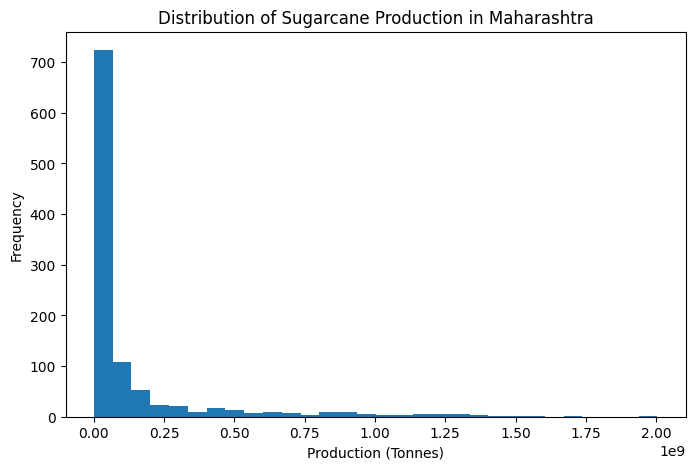

In [39]:
plt.figure(figsize=(8,5))

plt.hist(df["Production"], bins=30)

plt.xlabel("Production (Tonnes)")

plt.ylabel("Frequency")

plt.title("Distribution of Sugarcane Production in Maharashtra")

plt.show()

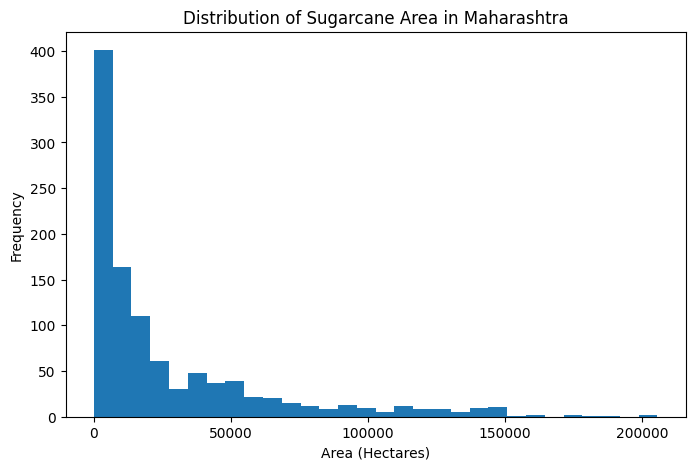

In [40]:
plt.figure(figsize=(8,5))

plt.hist(df["Area"], bins=30)

plt.xlabel("Area (Hectares)")

plt.ylabel("Frequency")

plt.title("Distribution of Sugarcane Area in Maharashtra")

plt.show()

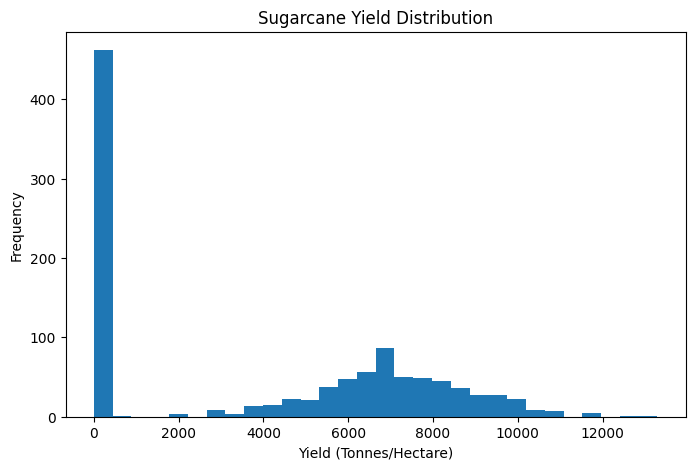

In [41]:
df["Yield"] = df["Production"] / df["Area"]

plt.figure(figsize=(8,5))

plt.hist(df["Yield"], bins=30)

plt.xlabel("Yield (Tonnes/Hectare)")

plt.ylabel("Frequency")

plt.title("Sugarcane Yield Distribution")

plt.show()

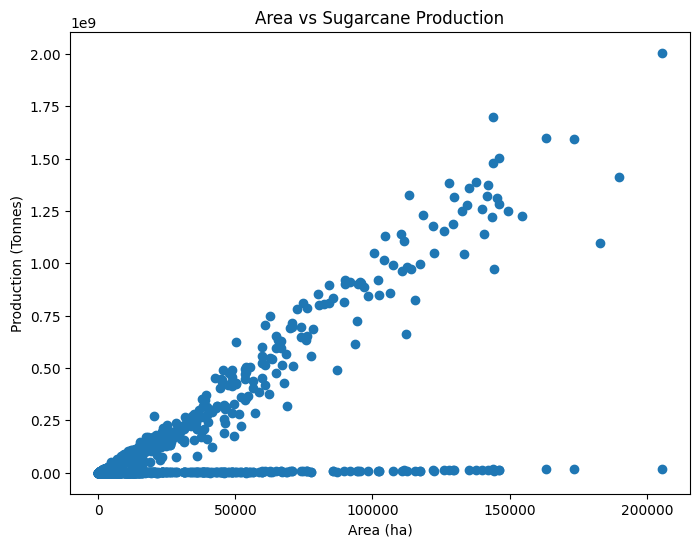

In [42]:
plt.figure(figsize=(8,6))

plt.scatter(df["Area"], df["Production"])

plt.xlabel("Area (ha)")

plt.ylabel("Production (Tonnes)")

plt.title("Area vs Sugarcane Production")

plt.show()

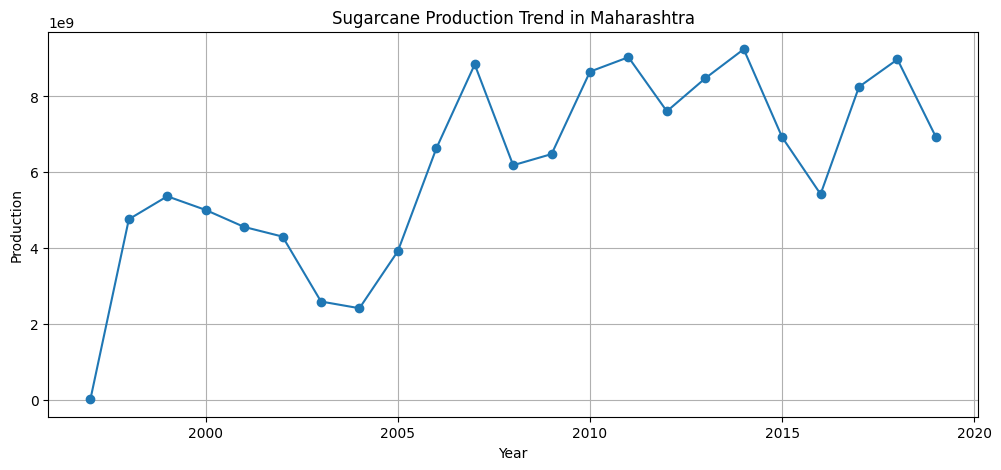

In [43]:

yearly = df.groupby("Crop_Year")["Production"].sum()

plt.figure(figsize=(12,5))

plt.plot(yearly.index, yearly.values, marker='o')

plt.xlabel("Year")

plt.ylabel("Production")

plt.title("Sugarcane Production Trend in Maharashtra")

plt.grid()

plt.show()

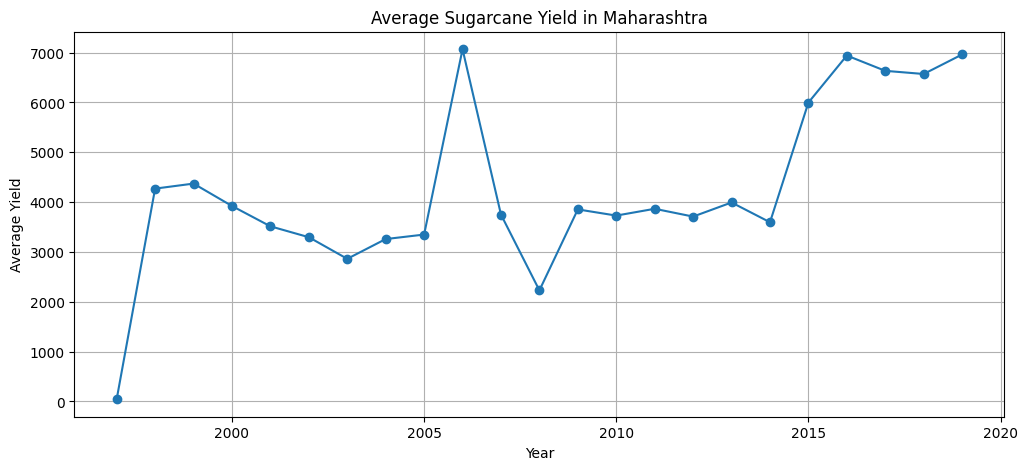

In [44]:
yield_year = df.groupby("Crop_Year")["Yield"].mean()

plt.figure(figsize=(12,5))

plt.plot(yield_year.index, yield_year.values, marker='o')

plt.xlabel("Year")

plt.ylabel("Average Yield")

plt.title("Average Sugarcane Yield in Maharashtra")

plt.grid()

plt.show()

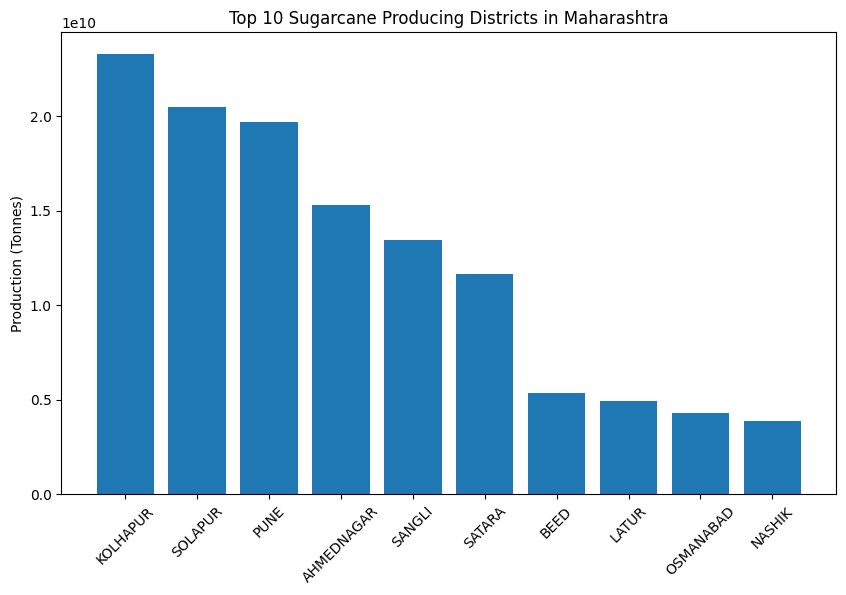

In [45]:
district = (
    df.groupby("District_Name")["Production"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10,6))

plt.bar(district.index, district.values)

plt.xticks(rotation=45)

plt.ylabel("Production (Tonnes)")

plt.title("Top 10 Sugarcane Producing Districts in Maharashtra")

plt.show()

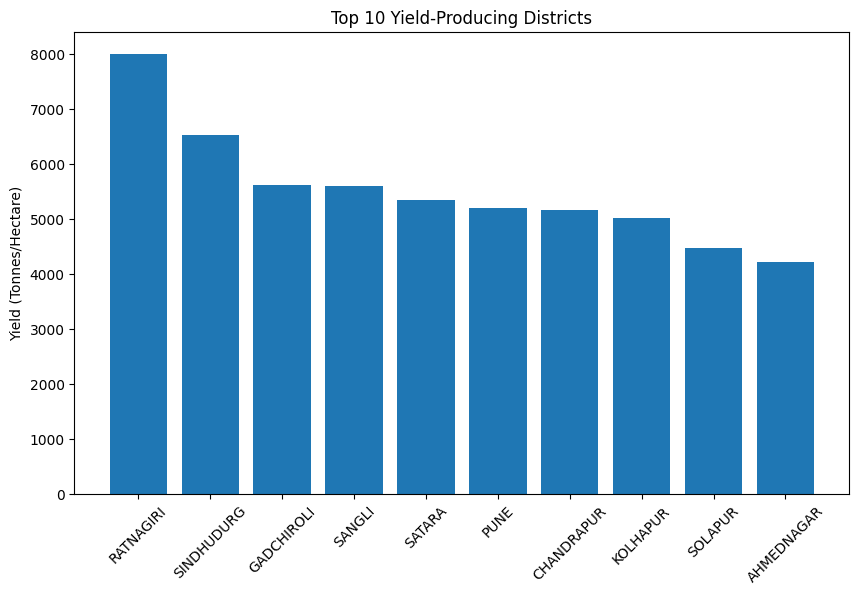

In [46]:
yield_dist = (
    df.groupby("District_Name")["Yield"]
      .mean()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10,6))

plt.bar(yield_dist.index, yield_dist.values)

plt.xticks(rotation=45)

plt.ylabel("Yield (Tonnes/Hectare)")

plt.title("Top 10 Yield-Producing Districts")

plt.show()

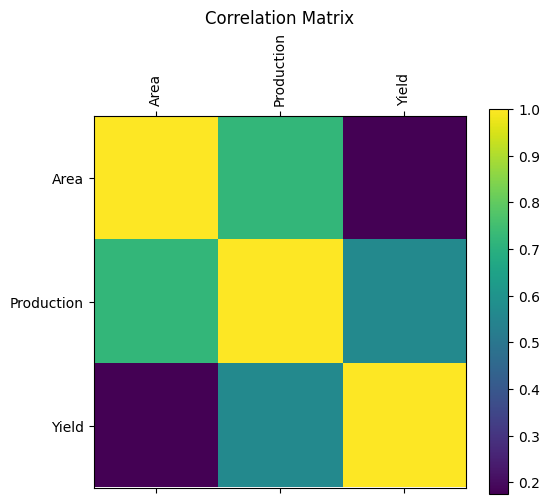

In [47]:

numeric = df[["Area", "Production", "Yield"]]

corr = numeric.corr()

fig = plt.figure(figsize=(6,5))
ax = fig.add_subplot(111)

cax = ax.matshow(corr)

fig.colorbar(cax)

ax.set_xticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=90)

ax.set_yticks(range(len(corr.columns)))
ax.set_yticklabels(corr.columns)

plt.title("Correlation Matrix")

plt.show()

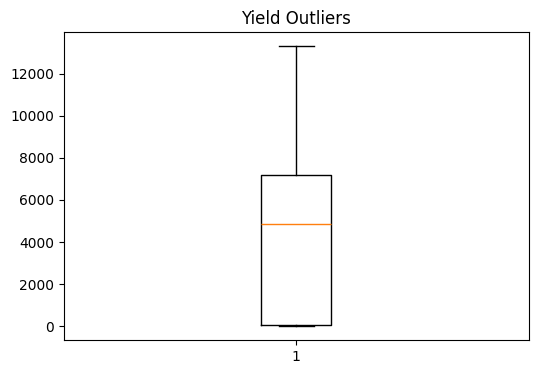

In [48]:
plt.figure(figsize=(6,4))

plt.boxplot(df["Yield"])

plt.title("Yield Outliers")

plt.show()

In [49]:

print(df[df["Area"] <= 0])

print(df[df["Production"] <= 0])

print(df[df["Yield"] <= 0])

Empty DataFrame
Columns: [State_Name, District_Name, Crop_Year, Season, Crop, Area, Production, yield, Yield]
Index: []
Empty DataFrame
Columns: [State_Name, District_Name, Crop_Year, Season, Crop, Area, Production, yield, Yield]
Index: []
Empty DataFrame
Columns: [State_Name, District_Name, Crop_Year, Season, Crop, Area, Production, yield, Yield]
Index: []


In [50]:
from sklearn.impute import SimpleImputer

num_cols = df.select_dtypes(include=['int64','float64']).columns

num_imputer = SimpleImputer(strategy='median')

df[num_cols] = num_imputer.fit_transform(df[num_cols])

In [51]:
df = df[df["Area"] > 0]

df = df[df["Production"] > 0]

In [52]:
df["Yield"] = df["Production"] / df["Area"]


In [53]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df["District_Name"] = encoder.fit_transform(df["District_Name"])

df["Season"] = encoder.fit_transform(df["Season"])

In [54]:
df = df.drop(columns=['State_Name','Crop'])

In [55]:
df

,District_Name,Crop_Year,Season,Area,Production,yield,Yield
122685,0,1997.0,0,45900.0,38940.0,0.848366,0.848366
122709,0,1998.0,0,59600.0,5231800.0,87.781879,87.781879
122756,0,1999.0,1,66600.0,5962900.0,89.533033,89.533033
122786,0,2000.0,1,67100.0,5163900.0,76.958271,76.958271
122818,0,2001.0,1,52000.0,3596300.0,69.159615,69.159615
...,...,...,...,...,...,...,...
554779,29,1999.0,1,1800.0,16830000.0,9350.000000,9350.000000
554780,29,2000.0,1,2800.0,18690000.0,6675.000000,6675.000000
554781,30,1998.0,0,6500.0,53850000.0,8284.615385,8284.615385
554782,30,1999.0,1,7000.0,64990000.0,9284.285714,9284.285714


In [56]:
X = df.drop(["Yield"], axis=1)

y = df["Yield"]

In [57]:

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [58]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)


In [59]:
X_train.shape

(846, 6)

In [60]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [61]:
y_pred_lr = lr.predict(X_test)

In [62]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error,accuracy_score


In [63]:
r2_score(y_test,y_pred_lr)

1.0

In [64]:
mean_absolute_error(y_test,y_pred_lr)

8.922237686615978e-12

In [65]:
mean_squared_error(y_test,y_pred_lr)

1.294691177238879e-22

In [66]:

from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(random_state=42)

dt.fit(X_train,y_train)
y_pred_dt = dt.predict(X_test)

In [67]:
r2_score(y_test,y_pred_dt)

0.9999586902309866

In [68]:
mean_absolute_error(y_test,y_pred_dt)

7.580928949877962

In [69]:
# predict the model for each algorithm Linear regression, Decision tree regressor, Random forest regressor, xgboosting regressor predict the model and make a simple streamlit webpage that predict the crop yield on the basic of land and who much water requried to this yield

In [70]:

from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)

rf.fit(X_train,y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [71]:
y_pred_rf = rf.predict(X_test)

In [72]:
r2_score(y_test,y_pred_rf)

0.9999806592479045

In [73]:
# from sklearn.ensemble import GradientBoostingRegressor

# model = GradientBoostingRegressor(random_state=42)

# model.fit(X_train,y_train)

In [74]:

from xgboost import XGBRegressor

xg = XGBRegressor(random_state=42)

xg.fit(X_train,y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [75]:
y_pred_xg = xg.predict(X_test)

In [76]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor

param_grid = {
    "n_estimators":[100,200,300,500],
    "max_depth":[5,10,20,None],
    "min_samples_split":[2,5,10],
    "min_samples_leaf":[1,2,4]
}

rf = RandomForestRegressor(random_state=42)

search = RandomizedSearchCV(
    rf,
    param_grid,
    n_iter=20,
    cv=5,
    scoring="r2",
    random_state=42,
    n_jobs=-1
)

search.fit(X_train,y_train)

best_model = search.best_estimator_

print(search.best_params_)

{'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 20}


In [77]:
optimized_rf = RandomForestRegressor(
    n_estimators=200,
    min_samples_split=2,
    min_samples_leaf=1,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)

In [78]:
optimized_rf.fit(X_train, y_train)

y_pred_optimized_rf = optimized_rf.predict(X_test)

In [79]:
r2_score(y_test,y_pred_optimized_rf)

0.9999832304894043

In [80]:


# 1. Update parameter grid with XGBoost hyperparameters
param_grid = {
    "n_estimators":[100,200,300,500],
    "max_depth":[5,10,20,None],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "min_child_weight": [1, 3, 5]
}


xgb = XGBRegressor(random_state=42, n_jobs=1)


search = RandomizedSearchCV(
    xgb,
    param_grid,
    n_iter=20,
    cv=5,
    scoring="r2",
    random_state=42,
    n_jobs=-1
)


search.fit(X_train, y_train)

best_model = search.best_estimator_

print("Best Parameters Found:")
print(search.best_params_)


Best Parameters Found:
{'subsample': 0.8, 'n_estimators': 500, 'min_child_weight': 3, 'max_depth': 10, 'learning_rate': 0.1, 'colsample_bytree': 1.0}


In [81]:
optimized_xgb = XGBRegressor(
    subsample=0.8,
    n_estimators=500,
    min_child_weight=3,
    max_depth=10,
    learning_rate=0.1,
    colsample_bytree=1.0,
    random_state=42,    # Ensures reproducible results
    n_jobs=-1           # Uses all CPU cores for fast standalone training
)

In [82]:
optimized_xgb.fit(X_train, y_train)

y_pred_optimized_xgb = optimized_xgb.predict(X_test)

In [83]:
r2_score(y_test,y_pred_optimized_xgb)

0.9988599361084867

In [84]:
df

,District_Name,Crop_Year,Season,Area,Production,yield,Yield
122685,0,1997.0,0,45900.0,38940.0,0.848366,0.848366
122709,0,1998.0,0,59600.0,5231800.0,87.781879,87.781879
122756,0,1999.0,1,66600.0,5962900.0,89.533033,89.533033
122786,0,2000.0,1,67100.0,5163900.0,76.958271,76.958271
122818,0,2001.0,1,52000.0,3596300.0,69.159615,69.159615
...,...,...,...,...,...,...,...
554779,29,1999.0,1,1800.0,16830000.0,9350.000000,9350.000000
554780,29,2000.0,1,2800.0,18690000.0,6675.000000,6675.000000
554781,30,1998.0,0,6500.0,53850000.0,8284.615385,8284.615385
554782,30,1999.0,1,7000.0,64990000.0,9284.285714,9284.285714
